# Citi Bike: GPU-tuned XGBoost

**Contribution owner: Tomislav Novosel.** Implementation, experiments and initial explanations were prepared with AI assistance on 9 October 2026. Human review and substantive changes should be recorded when they happen; see [the assistance record](../docs/AI_USE.md).

These are development experiments, not final-test results. The training/tuning dates end in June; July-September is development validation. October-December has not been scored.

The searches were executed with the helper scripts and their actual reports are saved. By default this notebook reviews those reports quickly. Set `CITIBIKE_RETRAIN=1` or use the runner's `--train` option to execute the search again. The XGBoost search needs a CUDA GPU; viewing results and running the saved app do not.


Boosting adds small trees that correct earlier mistakes. We also test learning the change from last week rather than the entire ride count. This lets last week supply the current level.

In [9]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd()
while not (ROOT / 'src/citibike_forecast.py').exists():
    if ROOT == ROOT.parent:
        raise RuntimeError('Open the notebook inside the repository.')
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import pandas as pd
import numpy as np
from citibike_forecast import REPORTS, MODELS, development_data, chronological_cv
RUN_TRAINING = os.environ.get('CITIBIKE_RETRAIN') == '1'
def report(name):
    return json.loads((REPORTS / (name + '_run.json')).read_text(encoding='utf8'))
print('Mode:', 'execute training' if RUN_TRAINING else 'review actual saved experiments')
from citibike_forecast import run_tuning
if RUN_TRAINING:
    run_tuning('xgboost')
run = report('xgboost_tuned')
display(pd.Series(run['search']))
grid = pd.read_csv(REPORTS / 'xgboost_grid.csv').sort_values('rank_test_score')
display(grid.filter(regex='param_|mean_test_score|rank_test_score').head(10))
assert run['search']['actual_fitted_device'].startswith('cuda')


Mode: review actual saved experiments


method                                                             GridSearchCV
configurations                                                              192
cv_fits                                                                     576
best_parameters               {'model__learning_rate': 0.03, 'model__max_dep...
best_cv_mae                                                        14058.179381
elapsed_seconds                                                      111.178652
actual_fitted_device                                                     cuda:0
validation_used_for_search                                                False
dtype: object

,param_model__learning_rate,param_model__max_depth,param_model__min_child_weight,param_model__n_estimators,param_model__reg_lambda,param_model__subsample,param_seasonal_residual,mean_test_score,rank_test_score
19,0.03,2,10,100,1.0,1.0,True,-14058.179381,1
1,0.03,2,3,100,1.0,0.8,True,-14103.695634,2
13,0.03,2,3,300,10.0,0.8,True,-14167.017016,3
3,0.03,2,3,100,1.0,1.0,True,-14188.075056,4
17,0.03,2,10,100,1.0,0.8,True,-14221.969874,5
7,0.03,2,3,100,10.0,1.0,True,-14296.989694,6
23,0.03,2,10,100,10.0,1.0,True,-14315.961755,7
29,0.03,2,10,300,10.0,0.8,True,-14393.558817,8
31,0.03,2,10,300,10.0,1.0,True,-14421.365775,9
5,0.03,2,3,100,10.0,0.8,True,-14421.664942,10


The actual search used RTX 5080 CUDA training: 192 configurations and 576 temporal CV fits. The best uses shallow trees and a residual target. Its configuration is chosen before July validation.

In [10]:
display(pd.Series(run['validation']))
print('Selected trees:', run['search']['best_parameters'])
print('The prediction artifact uses CPU inference so a laptop or host does not need a GPU.')


Selected trees: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__min_child_weight': 10, 'model__n_estimators': 100, 'model__reg_lambda': 1.0, 'model__subsample': 1.0, 'seasonal_residual': True}
The prediction artifact uses CPU inference so a laptop or host does not need a GPU.


mae     14692.652301
rmse    23426.393863
wape        0.121829
bias     3763.623936
days       92.000000
dtype: float64

The line chart shows both typical tracking and some large misses. We do not add actual same-day weather after seeing those mistakes.

No event loop hook running.


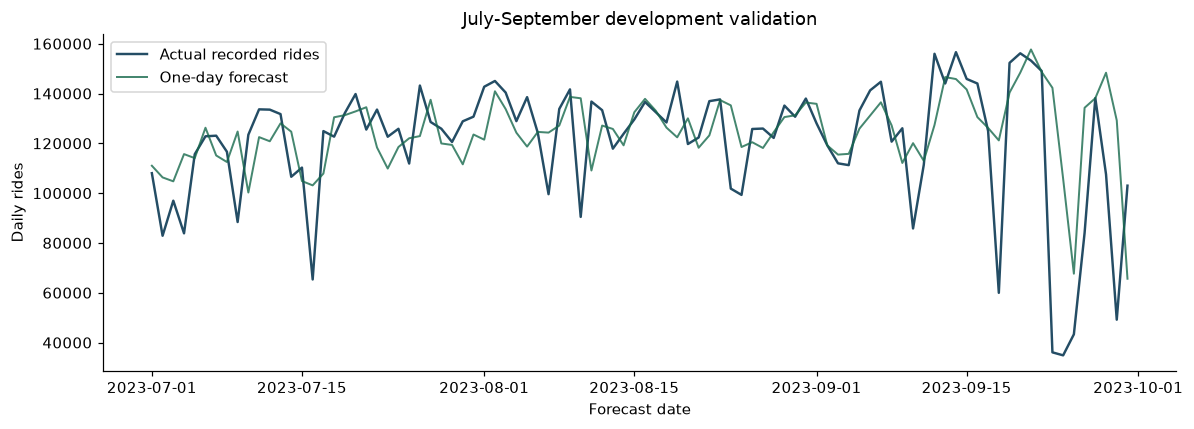

In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})
FIGURES = ROOT / 'citibike/figures'
pred = pd.read_csv(REPORTS / 'xgboost_tuned_validation.csv', parse_dates=['date']).set_index('date')
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(pred.index, pred.actual, color='#244d65', label='Actual recorded rides', linewidth=1.6)
ax.plot(pred.index, pred.predicted, color='#17694c', label='One-day forecast', linewidth=1.3, alpha=.8)
ax.set(title='July-September development validation', ylabel='Daily rides', xlabel='Forecast date')
ax.legend(); fig.tight_layout(); fig.savefig(FIGURES / 'forecast_validation.png', dpi=150); plt.show()
